# Comparative Analysis: Cascade vs 5G NR LDPC (Standard) vs Winnow vs Polar Codes
## BB84 QKD Reconciliation Protocols

This notebook provides a detailed comparison between four major reconciliation protocols used in Quantum Key Distribution:
1.  **Cascade**: An interactive, multi-pass protocol based on binary search.
2.  **5G NR LDPC (Standard)**: A high-performance protocol using 5G New Radio LDPC codes (NVIDIA Sionna).
3.  **Winnow**: An interactive protocol using Hamming codes to correct errors with fewer round trips than Cascade.
4.  **Polar Codes**: An advanced interactive scheme using Polar decoding capable of approaching channel capacity.

We evaluate them based on:
*   **Leakage**: How much key material is sacrificed.
*   **Efficiency**: Proximity to the Shannon Limit.
*   **Latency**: Number of network round-trips required.
*   **Speed**: Computational execution time.

In [1]:
import asyncio
import random
import sys
import os
import math
import time
import matplotlib.pyplot as plt
import numpy as np

# Ensure we can import from the ServerClientBB84 directory
current_dir = os.getcwd()
target_dir = os.path.join(current_dir, 'ServerClientBB84')
if target_dir not in sys.path:
    sys.path.append(target_dir)

try:
    from bb84_server_client import AliceServer, BobClient, QuantumChannel, Detector, Eve, APIClient
except ImportError:
    sys.path.append(os.getcwd())
    from bb84_server_client import AliceServer, BobClient, QuantumChannel, Detector, Eve, APIClient

# Enable inline plotting
%matplotlib inline

print("Libraries imported successfully.")
print("Note: This notebook requires Sionna and TensorFlow for NR LDPC.")

[NR-LDPC] GPU Detected: 1 device(s). Acceleration ENABLED.
[NR-LDPC] Sionna Library Loaded Successfully.
Libraries imported successfully.
Note: This notebook requires Sionna and TensorFlow for NR LDPC.


In [2]:
async def run_comparison_simulation(protocol="cascade", 
                                    num_qubits=5000, 
                                    optical_error_rate=0.01,
                                    verbose=False):
    """
    Runs a single BB84 simulation using the specified reconciliation protocol.
    Args:
        protocol (str): "cascade", "nr_ldpc_std", "winnow", or "polar"
        num_qubits (int): input block size
        optical_error_rate (float): simulated channel error
    """
    seed_base = 44444
    
    channel = QuantumChannel("Fiber", length_km=50, attenuation_db=0.2, 
                             optical_error_rate=optical_error_rate, next_actor=None, seed=seed_base)
    
    alice = AliceServer("Alice", channel, num_qubits=num_qubits, verbose=verbose, seed=seed_base+1)
    api = APIClient(alice)
    
    # 3. Setup Bob with Specific Protocol
    bob = BobClient("Bob", api, protocol=protocol, seed=seed_base+2, verbose=verbose)
    
    detector = Detector("Detector", efficiency=0.8, dark_count_prob=0.01, parent_bob=bob, seed=seed_base+3)

    eve = Eve("Eve", next_actor=detector, intercept_rate=0.2, seed=seed_base+5)
    channel.next_actor = eve
    
    actors = [alice, channel, eve, detector, bob]
    tasks = [asyncio.create_task(a.start()) for a in actors]
    
    results = {}
    try:
        start_time = time.time()
        await alice.run_quantum_transmission()
        
        wait_time = 0.5 + (num_qubits * 0.0001)
        await asyncio.sleep(wait_time)
        
        results = await bob.run_classical_post_processing(num_qubits)
        end_time = time.time()
        results["exec_time"] = end_time - start_time
        
    except Exception as e:
        print(f"Error in {protocol} sim: {e}")
        # Return empty/failed result to avoid crash
        results = {'sifted_length': 0}
    finally:
        for a in actors:
            await a.send(a, ("STOP",))
        await asyncio.gather(*tasks)
        
    return results

def binary_entropy(p):
    if p <= 0 or p >= 1: return 0.0
    return -p * math.log2(p) - (1 - p) * math.log2(1 - p)

def calculate_efficiency(n_revealed, k_sifted, qber):
    if k_sifted == 0 or qber <= 0 or qber >= 1: return None
    h_eps = binary_entropy(qber)
    if h_eps == 0: return None
    return n_revealed / (k_sifted * h_eps)

print("Simulation driver and metrics defined.")

Simulation driver and metrics defined.


In [3]:
# --- Experiment 1: Impact of QBER ---

# NR LDPC might fail at very high QBER without lower rate codes, so range is somewhat limited
error_rates = np.linspace(0.001, 0.12, 25) 

results_cascade = {"qber": [], "leakage": [], "efficiency": [], "uses": []}
results_nr = {"qber": [], "leakage": [], "efficiency": [], "uses": []}
results_winnow = {"qber": [], "leakage": [], "efficiency": [], "uses": []}
results_polar = {"qber": [], "leakage": [], "efficiency": [], "uses": []}

N_QUBITS = 100000

print(f"Running QBER Sweep (N={N_QUBITS})...")

for err in error_rates:
    print(f"Testing Optical Error: {err:.3f}...", end="\r")
    
    # 1. Cascade
    res_c = await run_comparison_simulation("cascade", N_QUBITS, err)
    if res_c.get('sifted_length', 0) > 0 and res_c.get('qber', 0) > 0:
        eff = calculate_efficiency(res_c['revealed'], res_c['final_length'], res_c['qber'])
        if eff:
            results_cascade["qber"].append(res_c['qber'] * 100)
            results_cascade["leakage"].append((res_c['revealed'] / res_c['final_length']) * 100)
            results_cascade["efficiency"].append(eff)
            results_cascade["uses"].append(res_c['channel_uses'])

    # 2. NR LDPC Standard (Sionna)
    # Using default rate ~0.33 which is good for moderate error
    # The protocol handles puncturing for lower QBER
    res_nr = await run_comparison_simulation("nr_ldpc_std", N_QUBITS, err)
    if res_nr.get('sifted_length', 0) > 0 and res_nr.get('qber', 0) > 0:
        eff = calculate_efficiency(res_nr['revealed'], res_nr['final_length'], res_nr['qber'])
        if eff:
            results_nr["qber"].append(res_nr['qber'] * 100)
            results_nr["leakage"].append((res_nr['revealed'] / res_nr['final_length']) * 100)
            results_nr["efficiency"].append(eff)
            results_nr["uses"].append(res_nr['channel_uses'])

    # 3. Winnow
    res_w = await run_comparison_simulation("winnow", N_QUBITS, err)
    if res_w.get('sifted_length', 0) > 0 and res_w.get('qber', 0) > 0:
        eff = calculate_efficiency(res_w['revealed'], res_w['final_length'], res_w['qber'])
        if eff:
            results_winnow["qber"].append(res_w['qber'] * 100)
            results_winnow["leakage"].append((res_w['revealed'] / res_w['final_length']) * 100)
            results_winnow["efficiency"].append(eff)
            results_winnow["uses"].append(res_w['channel_uses'])
            
    # 4. Polar Codes
    res_p = await run_comparison_simulation("polar", N_QUBITS, err)
    if res_p.get('sifted_length', 0) > 0 and res_p.get('qber', 0) > 0:
        eff = calculate_efficiency(res_p['revealed'], res_p['final_length'], res_p['qber'])
        if eff:
            results_polar["qber"].append(res_p['qber'] * 100)
            results_polar["leakage"].append((res_p['revealed'] / res_p['final_length']) * 100)
            results_polar["efficiency"].append(eff)
            results_polar["uses"].append(res_p['channel_uses'])

print("\nExperiment 1 Complete.")

Running QBER Sweep (N=100000)...
Testing Optical Error: 0.001...
[BOB] Processing 7957 detection events.
[BOB] First 15 Valid Detections: 1(+), 1(x), 1(+), 0(x), 0(+), 0(x), 1(+), 0(+), 1(+), 1(+), 0(+), 1(+), 1(x), 0(x), 0(+) ...
[BOB] Sending 7957 bases to Alice for sifting...
[BOB] Sifting complete. Bases matched on 3993 events.
[BOB] Sifted Key Preview: [1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1]...
[BOB] Sampling 798 bits for QBER estimation...
[BOB] QBER Analysis: 37 errors in 798 samples. Estimated QBER = 4.64%
[BOB] Discarding revealed bits. Working Key Size: 3195
[BOB] Initializing Cascade Protocol...

[BOB] Processing 7957 detection events.
[BOB] First 15 Valid Detections: 1(+), 1(x), 1(+), 0(x), 0(+), 0(x), 1(+), 0(+), 1(+), 1(+), 0(+), 1(+), 1(x), 0(x), 0(+) ...
[BOB] Sending 7957 bases to Alice for sifting...
[BOB] Sifting complete. Bases matched on 3993 events.
[BOB] Sifted Key Preview: [1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1]...
[BOB]

I0000 00:00:1774007831.622553   63713 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4745 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5



[BOB] Processing 7957 detection events.
[BOB] First 15 Valid Detections: 1(+), 1(x), 1(+), 0(x), 0(+), 0(x), 1(+), 0(+), 1(+), 1(+), 0(+), 1(+), 1(x), 0(x), 0(+) ...
[BOB] Sending 7957 bases to Alice for sifting...
[BOB] Sifting complete. Bases matched on 3993 events.
[BOB] Sifted Key Preview: [1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1]...
[BOB] Sampling 798 bits for QBER estimation...
[BOB] QBER Analysis: 37 errors in 798 samples. Estimated QBER = 4.64%
[BOB] Discarding revealed bits. Working Key Size: 3195
[BOB] Initializing Winnow Protocol...
[BOB] Selected Protocol: Winnow (4 passes)

[BOB] Processing 7957 detection events.
[BOB] First 15 Valid Detections: 1(+), 1(x), 1(+), 0(x), 0(+), 0(x), 1(+), 0(+), 1(+), 1(+), 0(+), 1(+), 1(x), 0(x), 0(+) ...
[BOB] Sending 7957 bases to Alice for sifting...
[BOB] Sifting complete. Bases matched on 3993 events.
[BOB] Sifted Key Preview: [1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1]...
[BOB] Sampling 798 bits for

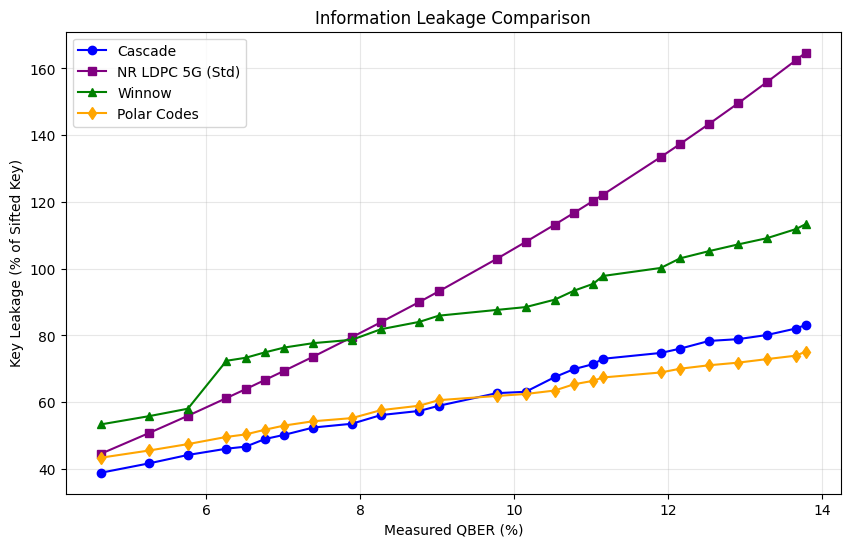

In [4]:
# --- Graph 1: Key Leakage vs QBER ---

plt.figure(figsize=(10, 6))

if len(results_cascade["qber"]) > 0:
    idx_c = np.argsort(results_cascade["qber"])
    plt.plot(np.array(results_cascade["qber"])[idx_c], 
             np.array(results_cascade["leakage"])[idx_c], 
             'o-', color='blue', label='Cascade')

if len(results_nr["qber"]) > 0:
    idx_l = np.argsort(results_nr["qber"])
    plt.plot(np.array(results_nr["qber"])[idx_l], 
             np.array(results_nr["leakage"])[idx_l], 
             's-', color='purple', label='NR LDPC 5G (Std)')

if len(results_winnow["qber"]) > 0:
    idx_w = np.argsort(results_winnow["qber"])
    plt.plot(np.array(results_winnow["qber"])[idx_w], 
             np.array(results_winnow["leakage"])[idx_w], 
             '^-', color='green', label='Winnow')

if len(results_polar["qber"]) > 0:
    idx_p = np.argsort(results_polar["qber"])
    plt.plot(np.array(results_polar["qber"])[idx_p], 
             np.array(results_polar["leakage"])[idx_p], 
             'd-', color='orange', label='Polar Codes')

plt.xlabel('Measured QBER (%)')
plt.ylabel('Key Leakage (% of Sifted Key)')
plt.title('Information Leakage Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

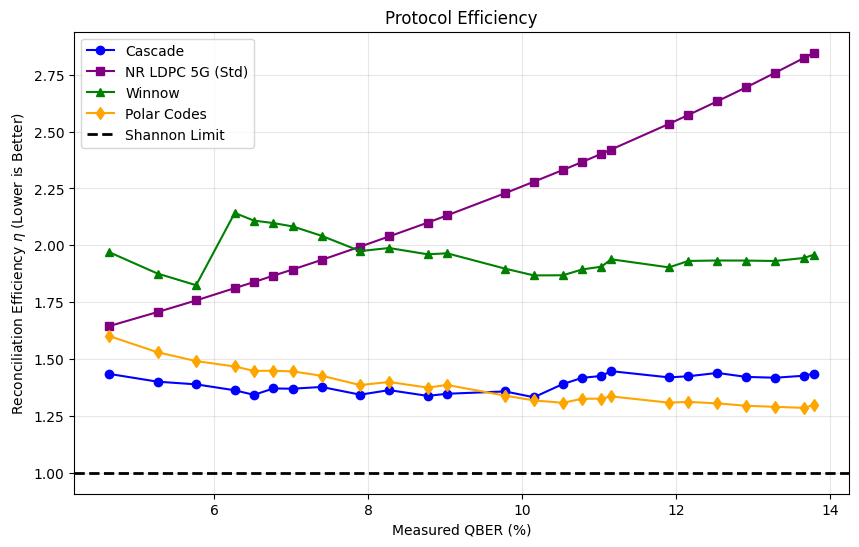

In [5]:
# --- Graph 2: Efficiency vs QBER ---

plt.figure(figsize=(10, 6))

if len(results_cascade["qber"]) > 0:
    idx_c = np.argsort(results_cascade["qber"])
    plt.plot(np.array(results_cascade["qber"])[idx_c], 
             np.array(results_cascade["efficiency"])[idx_c], 
             'o-', color='blue', label='Cascade')

if len(results_nr["qber"]) > 0:
    idx_l = np.argsort(results_nr["qber"])
    plt.plot(np.array(results_nr["qber"])[idx_l], 
             np.array(results_nr["efficiency"])[idx_l], 
             's-', color='purple', label='NR LDPC 5G (Std)')

if len(results_winnow["qber"]) > 0:
    idx_w = np.argsort(results_winnow["qber"])
    plt.plot(np.array(results_winnow["qber"])[idx_w], 
             np.array(results_winnow["efficiency"])[idx_w], 
             '^-', color='green', label='Winnow')

if len(results_polar["qber"]) > 0:
    idx_p = np.argsort(results_polar["qber"])
    plt.plot(np.array(results_polar["qber"])[idx_p], 
             np.array(results_polar["efficiency"])[idx_p], 
             'd-', color='orange', label='Polar Codes')

plt.axhline(y=1.0, color='black', linestyle='--', linewidth=2, label='Shannon Limit')

plt.xlabel('Measured QBER (%)')
plt.ylabel(r'Reconciliation Efficiency $\eta$ (Lower is Better)')
plt.title('Protocol Efficiency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

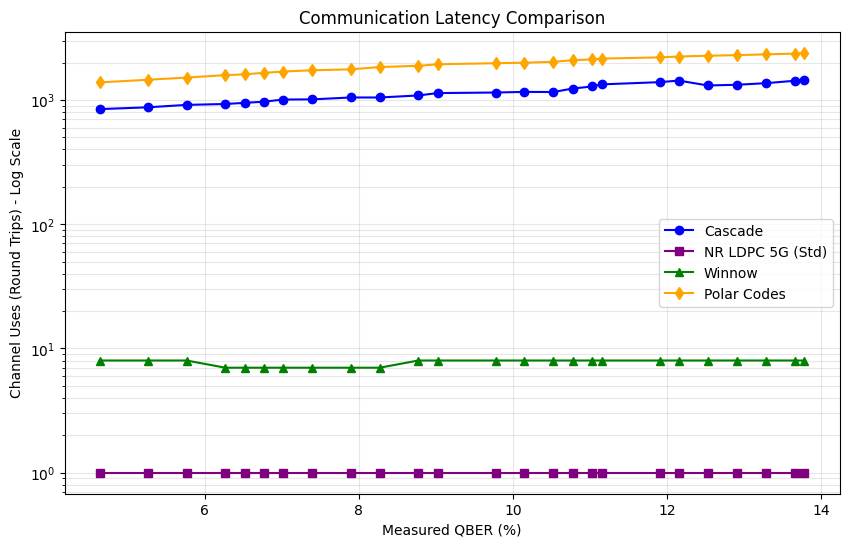

In [6]:
# --- Graph 3: Latency (Round Trips) vs QBER ---

plt.figure(figsize=(10, 6))

if len(results_cascade["qber"]) > 0:
    idx_c = np.argsort(results_cascade["qber"])
    plt.plot(np.array(results_cascade["qber"])[idx_c], 
             np.array(results_cascade["uses"])[idx_c], 
             'o-', color='blue', label='Cascade')

if len(results_nr["qber"]) > 0:
    idx_l = np.argsort(results_nr["qber"])
    plt.plot(np.array(results_nr["qber"])[idx_l], 
             np.array(results_nr["uses"])[idx_l], 
             's-', color='purple', label='NR LDPC 5G (Std)')

if len(results_winnow["qber"]) > 0:
    idx_w = np.argsort(results_winnow["qber"])
    plt.plot(np.array(results_winnow["qber"])[idx_w], 
             np.array(results_winnow["uses"])[idx_w], 
             '^-', color='green', label='Winnow')

if len(results_polar["qber"]) > 0:
    idx_p = np.argsort(results_polar["qber"])
    plt.plot(np.array(results_polar["qber"])[idx_p], 
             np.array(results_polar["uses"])[idx_p], 
             'd-', color='orange', label='Polar Codes')

plt.yscale('log')
plt.xlabel('Measured QBER (%)')
plt.ylabel('Channel Uses (Round Trips) - Log Scale')
plt.title('Communication Latency Comparison')
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [7]:
# --- Experiment 2: Computation Time vs Block Size ---

block_sizes = [1000, 2500, 5000, 10000, 20000]
time_cascade = []
time_nr = []
time_winnow = []
time_polar = []

FIXED_ERR = 0.02 # 2% error

print(f"Running Scalability Test (Error={FIXED_ERR})...")

for size in block_sizes:
    print(f"Testing Block Size: {size}...", end="\r")
    
    # Cascade
    res_c = await run_comparison_simulation("cascade", size, FIXED_ERR)
    time_cascade.append(res_c.get("exec_time", 0))
    
    # NR LDPC Standard (Sionna)
    res_l = await run_comparison_simulation("nr_ldpc_std", size, FIXED_ERR)
    time_nr.append(res_l.get("exec_time", 0))

    # Winnow
    res_w = await run_comparison_simulation("winnow", size, FIXED_ERR)
    time_winnow.append(res_w.get("exec_time", 0))

    # Polar
    res_p = await run_comparison_simulation("polar", size, FIXED_ERR)
    time_polar.append(res_p.get("exec_time", 0))

print("\nScalability Experiment Complete.")

Running Scalability Test (Error=0.02)...
Testing Block Size: 1000...
[BOB] Processing 83 detection events.
[BOB] First 15 Valid Detections: 1(+), 1(x), 1(+), 0(x), 0(+), 0(x), 1(+), 0(+), 1(+), 1(+), 0(+), 1(+), 1(x), 0(x), 0(+) ...
[BOB] Sending 83 bases to Alice for sifting...
[BOB] Sifting complete. Bases matched on 42 events.
[BOB] Sifted Key Preview: [1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1]...
[BOB] Adjusted sample size to minimum 10 bits.
[BOB] Sampling 10 bits for QBER estimation...
[BOB] QBER Analysis: 0 errors in 10 samples. Estimated QBER = 0.00%
[BOB] Discarding revealed bits. Working Key Size: 32
[BOB] Initializing Cascade Protocol...

[BOB] Processing 83 detection events.
[BOB] First 15 Valid Detections: 1(+), 1(x), 1(+), 0(x), 0(+), 0(x), 1(+), 0(+), 1(+), 1(+), 0(+), 1(+), 1(x), 0(x), 0(+) ...
[BOB] Sending 83 bases to Alice for sifting...
[BOB] Sifting complete. Bases matched on 42 events.
[BOB] Sifted Key Preview: [1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0

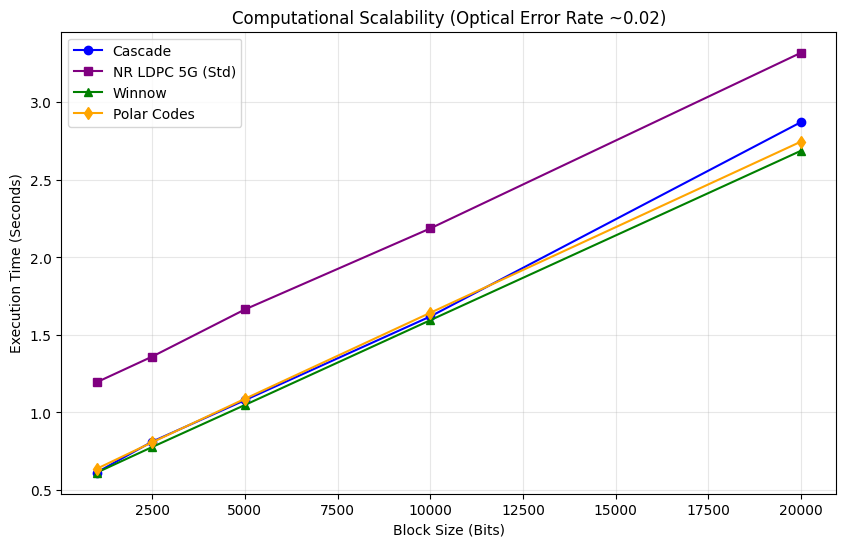

In [8]:
# --- Graph 4: Execution Time vs Block Size ---

plt.figure(figsize=(10, 6))

plt.plot(block_sizes, time_cascade, 'o-', color='blue', label='Cascade')
plt.plot(block_sizes, time_nr, 's-', color='purple', label='NR LDPC 5G (Std)')
plt.plot(block_sizes, time_winnow, '^-', color='green', label='Winnow')
plt.plot(block_sizes, time_polar, 'd-', color='orange', label='Polar Codes')

plt.xlabel('Block Size (Bits)')
plt.ylabel('Execution Time (Seconds)')
plt.title(f'Computational Scalability (Optical Error Rate ~{FIXED_ERR})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

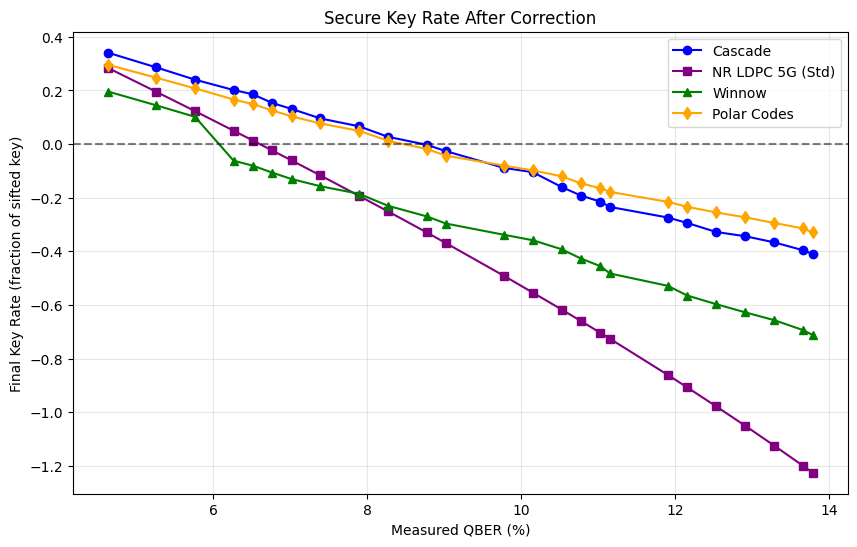

In [9]:
# --- Graph 5: Final Key Rate vs QBER ---

plt.figure(figsize=(10, 6))

if len(results_cascade["qber"]) > 0:
    idx_c = np.argsort(results_cascade["qber"])
    qber_c = np.array(results_cascade["qber"])[idx_c]
    eff_c = np.array(results_cascade["efficiency"])[idx_c]
    key_rate_c = [1 - (1 + eff) * binary_entropy(q/100) for eff,q in zip(eff_c,qber_c)]
    plt.plot(qber_c, key_rate_c, 'o-', color='blue', label='Cascade')

if len(results_nr["qber"]) > 0:
    idx_l = np.argsort(results_nr["qber"])
    qber_l = np.array(results_nr["qber"])[idx_l]
    eff_l = np.array(results_nr["efficiency"])[idx_l]
    key_rate_l = [1 - (1 + eff) * binary_entropy(q/100) for eff,q in zip(eff_l,qber_l)]
    plt.plot(qber_l, key_rate_l, 's-', color='purple', label='NR LDPC 5G (Std)')

if len(results_winnow["qber"]) > 0:
    idx_w = np.argsort(results_winnow["qber"])
    qber_w = np.array(results_winnow["qber"])[idx_w]
    eff_w = np.array(results_winnow["efficiency"])[idx_w]
    key_rate_w = [1 - (1 + eff) * binary_entropy(q/100) for eff,q in zip(eff_w,qber_w)]
    plt.plot(qber_w, key_rate_w, '^-', color='green', label='Winnow')

if len(results_polar["qber"]) > 0:
    idx_p = np.argsort(results_polar["qber"])
    qber_p = np.array(results_polar["qber"])[idx_p]
    eff_p = np.array(results_polar["efficiency"])[idx_p]
    key_rate_p = [1 - (1 + eff) * binary_entropy(q/100) for eff,q in zip(eff_p,qber_p)]
    plt.plot(qber_p, key_rate_p, 'd-', color='orange', label='Polar Codes')

plt.xlabel('Measured QBER (%)')
plt.ylabel('Final Key Rate (fraction of sifted key)')
plt.title('Secure Key Rate After Correction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.show()